In [1]:
#                <--History of PCA--> 
# * PCA was invented back in 1905, almost 120 year back.
# * It was invented by kearl pearson.

# * Objective --  Reduction of features(Feature which are not important) but without loosing much information
                      
# * Definition -- The PCA does not tell us from the existing features how important they are rather creates new feature 
#                 such that the first feature has highest amount of information & second feature has 2nd highest information
#                 & 3rd feature has the 3rd highest information. Each feature will have information in a descending order.
#                 
#  * In majority of the cases last few features have very minimal informations, so that we can simply throw them out.

#                 Ex: | employ name | age(years) | age(days) |    
#                                                  -- Here i can drop a feature between "age(years)" or "age(days)". so that 
#                                                     i can loose a feature but i do not loose much information.

# * Use case 1:
#            a) Feature reduction: 
#               | x1 | x2 | x3 | x4 | --Convert using PCA--> | z1 | z2 | z3 | z4 |
#                25%  25%  25%  25%                           80%   15%  3%   2%
#                 Here i am going to keep z1 and z2 so that i can save more information(95%) and clear 50% of memory space.

# * Use case 2:
#            b) Data visualisation: When we have more than 3 features we can not plot those data. Then using PCA we can reduce the
#                                   number of features and that will help us to plot the features.

# * Use case 3: 
#            c) In MLR one of the assumption says the feature should be independent of each other, if the features are not already independet
#               We can apply the PCA to make them independent.

# * Disadvantage of PCA -- 1) Significance of the features are losed after conversion using PCA.(After conversion name of that feature i cant know)
#                          2) PCA can not work for Non-linear data, PCA can help with linear data.
#                                ----How PCA Works?--
#                                      * PCA will first find out that direction of the data where changes is maximum, that will be your z1 (80%)
#                                      * Next it will be finding z2 (15%). z2 should be always perpendicular to z1, so the angle between 
#                                        z1 and z2 is 90 degree.
#                          3) PCA also can not work for independent data.(means they are not correlated)

# * How PCA works mathematically or math behind PCA---->
#         * If we multiply a matrix with a vector, we get to see two changes - 1) Magnitude and 2) Direction
#         * Given a matrix those vectors will be treated as eigen vectors for which it will be only be chaging the Magnitude but the direction will be remaining 
#           as it is. 


# Note: 1) For a supervised problem important feature always depends on target variable.
#       2) If the features are constant through out the all the rows, those features are not important.
#       3) In unsupervised problem if a feature has less variation that feature less important and vice-versa. 

import pandas as pd  
import numpy as np 
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=sns.load_dataset("iris")

In [3]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
x=df.iloc[:,:-1]
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
x.shape

(150, 4)

In [5]:
np.matmul(x.T,x).shape

(4, 4)

In [7]:
np.matmul(x.T,x)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,5223.85,2673.43,3483.76,1128.14
sepal_width,2673.43,1430.40,1674.30,531.89
petal_length,3483.76,1674.30,2582.71,869.11
petal_width,1128.14,531.89,869.11,302.33


In [9]:
w,v=np.linalg.eig(np.matmul(x.T,x))
w,v

(array([9.20830507e+03, 3.15454317e+02, 1.19780429e+01, 3.55257020e+00]),
 array([[ 0.75110816,  0.2841749 ,  0.50215472,  0.32081425],
        [ 0.38008617,  0.5467445 , -0.67524332, -0.31725607],
        [ 0.51300886, -0.70866455, -0.05916621, -0.48074507],
        [ 0.16790754, -0.34367081, -0.53701625,  0.75187165]]))

In [24]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [23]:
new_data=pd.DataFrame(np.matmul(x,v).values,columns=["pc1","pc2","pc3","pc4"])
new_data

,pc1,pc2,pc3,pc4
0,5.912747,2.302033,0.007402,0.003088
1,5.572482,1.971826,0.244592,0.097553
2,5.446977,2.095206,0.015029,0.018013
3,5.436459,1.870382,0.020505,-0.078492
4,5.875645,2.328290,-0.110338,-0.060719
...,...,...,...,...
145,9.226517,-0.931293,-0.204095,0.427118
146,8.566265,-1.039134,0.159305,0.252820
147,9.025923,-0.885027,-0.143421,0.137393
148,9.105599,-0.996416,-0.737103,0.043659


In [12]:
new_data.shape

(150, 4)

In [13]:
new_data["species"]=df["species"]

In [14]:
new_data

,pc1,pc2,pc3,pc4,species
0,5.912747,2.302033,0.007402,0.003088,setosa
1,5.572482,1.971826,0.244592,0.097553,setosa
2,5.446977,2.095206,0.015029,0.018013,setosa
3,5.436459,1.870382,0.020505,-0.078492,setosa
4,5.875645,2.328290,-0.110338,-0.060719,setosa
...,...,...,...,...,...
145,9.226517,-0.931293,-0.204095,0.427118,virginica
146,8.566265,-1.039134,0.159305,0.252820,virginica
147,9.025923,-0.885027,-0.143421,0.137393,virginica
148,9.105599,-0.996416,-0.737103,0.043659,virginica


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [16]:
X_train, X_test, y_train, y_test =train_test_split(new_data.iloc[:,0:1],new_data.iloc[:,-1])

In [17]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [18]:
print(classification_report(y_test,model.predict(X_test)))

              precision    recall  f1-score   support

      setosa       0.87      1.00      0.93        13
  versicolor       0.71      0.77      0.74        13
   virginica       0.89      0.67      0.76        12

    accuracy                           0.82        38
   macro avg       0.82      0.81      0.81        38
weighted avg       0.82      0.82      0.81        38



In [19]:
#lambda1,lambda2,lambda3,lambda4
np.round(w/sum(w),3)

array([0.965, 0.033, 0.001, 0.   ])

# plot

In [20]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

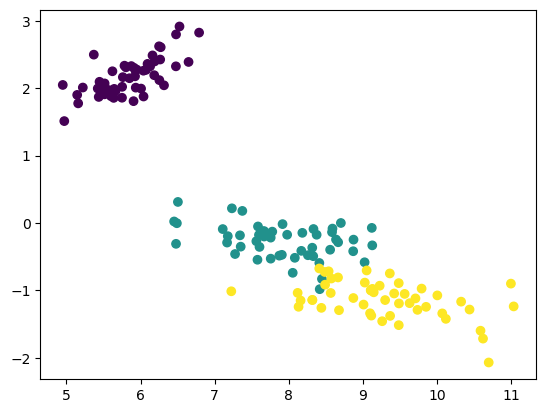

In [21]:
plt.scatter(new_data["pc1"],new_data["pc2"],c=encoder.fit_transform(new_data["species"]))
plt.show()

In [26]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


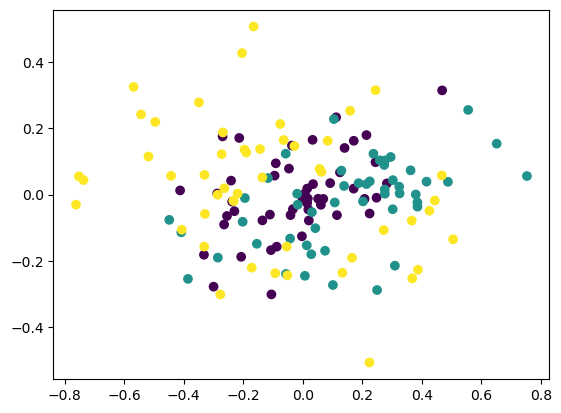

In [22]:
plt.scatter(new_data["pc3"],new_data["pc4"],c=encoder.fit_transform(new_data["species"]))
plt.show()